# 1- Exploration des données

In [1]:
pip install tensorflow

## Base de données

In [2]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

base_dir = r'C:\Users\djafa\Downloads\DONNEES_VISION_ORDINATEUR'
classes_choisies = ['left', 'right', 'up', 'down']

# Fonction pour charger et filtrer
def charger_donnees_filtrees(dossier):
    ds = tf.keras.utils.image_dataset_from_directory(
        dossier,
        labels='inferred',
        label_mode='int',
        class_names=classes_choisies, # On ne charge que ces 4-là !
        image_size=(180, 180),
        batch_size=32
    )
    return ds

train_ds = charger_donnees_filtrees(os.path.join(base_dir, 'Train'))
val_ds = charger_donnees_filtrees(os.path.join(base_dir, 'Validation'))
test_ds = charger_donnees_filtrees(os.path.join(base_dir, 'Test'))



Found 8000 files belonging to 4 classes.
Found 400 files belonging to 4 classes.
Found 1200 files belonging to 4 classes.


In [3]:
# 1. Inspecter la forme d'un lot (batch)
for images, labels in train_ds.take(1):
    print("Forme d'un lot d'images (batch_size, height, width, channels) :", images.shape)
    print("Forme des étiquettes :", labels.shape)

# 2. Connaître les noms des classes (tes 4 dossiers)
print("Classes détectées :", train_ds.class_names)

Forme d'un lot d'images (batch_size, height, width, channels) : (32, 180, 180, 3)
Forme des étiquettes : (32,)
Classes détectées : ['left', 'right', 'up', 'down']


## Visualisation de quelques images

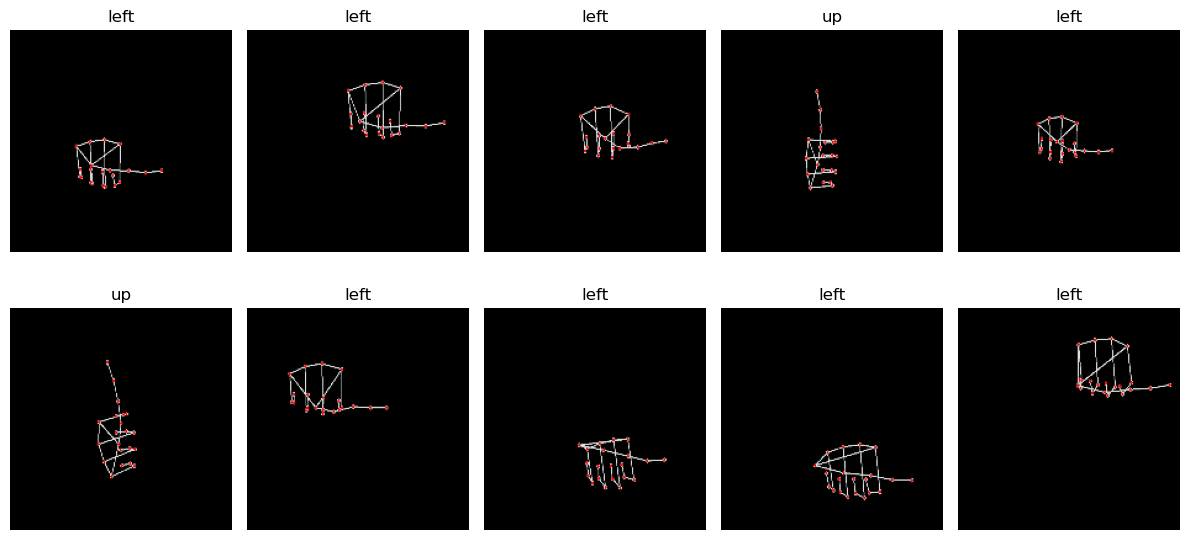

In [4]:

# 1. On récupère un seul lot (batch) de la base train_ds
images_batch, labels_batch = next(iter(train_ds))

# 2. Configuration de l'affichage
plt.figure(figsize=(12, 6))

# 3. Boucle pour afficher 10 images du lot
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Conversion des données pour matplotlib
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    
    # Utilisation de .class_names pour avoir le vrai nom du dossier
    label_index = labels_batch[i].numpy()
    plt.title(train_ds.class_names[label_index])
    
    plt.axis('off')

plt.tight_layout()
plt.savefig('DROITE') 
plt.show()


## Distribution des classes

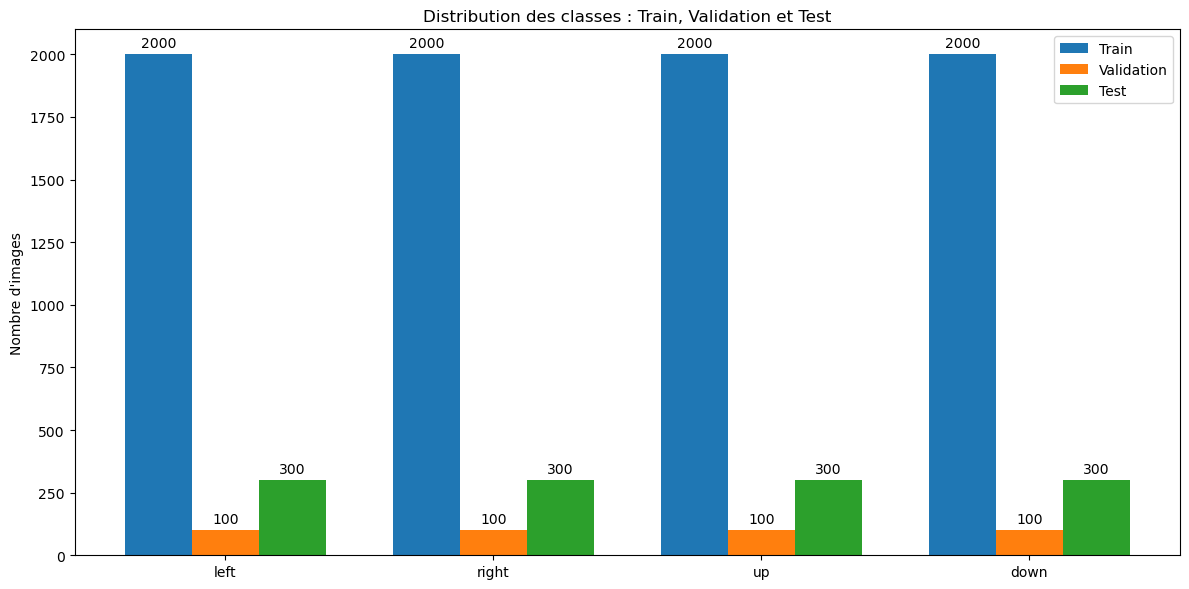

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Fonction pour compter les occurrences de chaque classe
def get_counts(ds):
    counts = {name: 0 for name in ds.class_names}
    for _, labels in ds:
        for label in labels.numpy():
            counts[ds.class_names[label]] += 1
    return counts

# 1. Calculer les distributions pour les trois bases
train_counts = get_counts(train_ds)
val_counts = get_counts(val_ds)
test_counts = get_counts(test_ds)

# 2. Préparation du graphique
classes = list(train_counts.keys())
x = np.arange(len(classes))
width = 0.25  # Largeur des barres

fig, ax = plt.subplots(figsize=(12, 6))

# 3. Création des trois groupes de barres
# On stocke chaque groupe dans une variable (r1, r2, r3)
r1 = ax.bar(x - width, train_counts.values(), width, label='Train')
r2 = ax.bar(x, val_counts.values(), width, label='Validation')
r3 = ax.bar(x + width, test_counts.values(), width, label='Test')

# Ajout des nombres exacts au-dessus de chaque barre
ax.bar_label(r1, padding=3)
ax.bar_label(r2, padding=3)
ax.bar_label(r3, padding=3)

# 4. Mise en forme et légendes
ax.set_ylabel('Nombre d\'images')
ax.set_title('Distribution des classes : Train, Validation et Test')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.tight_layout()
plt.savefig('Distribution')
plt.show()

# 2- Prétraitement des données

## Normalisation des données

In [6]:


# 1. Définir la fonction de normalisation
def normaliser(image, label):
    # tf.cast convertit les entiers en flottants
    # / 255.0 met les valeurs entre 0 et 1
    return tf.cast(image, tf.float32) / 255.0, label

# 2. Appliquer la normalisation aux trois bases

train_ds = train_ds.map(normaliser)
val_ds = val_ds.map(normaliser)
test_ds = test_ds.map(normaliser)



## Transformer les étiquettes en vecteurs one-hot (encodage catégoriel)

In [7]:
# 1. Définir le nombre de classes (tes 4 dossiers)
num_classes = 4

# 2. Fonction pour convertir le label en One-Hot
def one_hot_label(image, label):
    # tf.one_hot transforme l'entier (ex: 2) en vecteur (ex: [0, 0, 1, 0])
    return image, tf.one_hot(label, num_classes)

# 3. Application aux trois bases
train_ds = train_ds.map(one_hot_label)
val_ds = val_ds.map(one_hot_label)
test_ds = test_ds.map(one_hot_label)



# 3- Modèle MLP

## Construction du modèle

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Définition du modèle MLP
model = keras.Sequential([
    # 1. Aplatir les images 180x180x3 en un vecteur 1D
    layers.Flatten(input_shape=(180, 180, 3)),
    
    # 2. Couche cachée (Dense)
    layers.Dense(128, activation='relu'),
    
    # 3. Couche de sortie avec 4 neurones (tes 4 gestes)
    layers.Dense(4, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Affichage du résumé pour vérifier la structure
model.summary()

C:\Users\djafa\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 97200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,441,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,442,244 (47.46 MB)

 Trainable params: 12,442,244 (47.46 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:


# Entraînement du modèle 

historique = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=100
)

# Évaluation du modèle sur les données de test

test_loss, test_accuracy = model.evaluate(test_ds, verbose=2)

# Afficher la précision du modèle sur les données de test
print(f'Précision sur les données de test : {test_accuracy*100:.2f}%')

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 203ms/step - accuracy: 0.9032 - loss: 0.2597 - val_accuracy: 0.9450 - val_loss: 0.1555
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.9992 - loss: 0.0056 - val_accuracy: 0.9575 - val_loss: 0.1315
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 1.0000 - loss: 9.0557e-04 - val_accuracy: 0.9475 - val_loss: 0.1318
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 1.0000 - loss: 5.0618e-04 - val_accuracy: 0.9550 - val_loss: 0.1252
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 1.0000 - loss: 3.6618e-04 - val_accuracy: 0.9600 - val_loss: 0.1271
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 203ms/step - accuracy: 1.0000 - loss: 2.9674e-04 - val_accuracy: 0.9600 - val_loss: 0.1277
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 200ms/step - accuracy: 1.0000 - loss: 2.5730e-04 - val_accuracy: 0.9575 - val_loss: 0.1273
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1188s 246ms/step 


--- Évaluation finale sur le jeu de test ---
38/38 - 2s - 62ms/step - accuracy: 0.8075 - loss: 1.2058
Précision sur les données de test : 80.75%


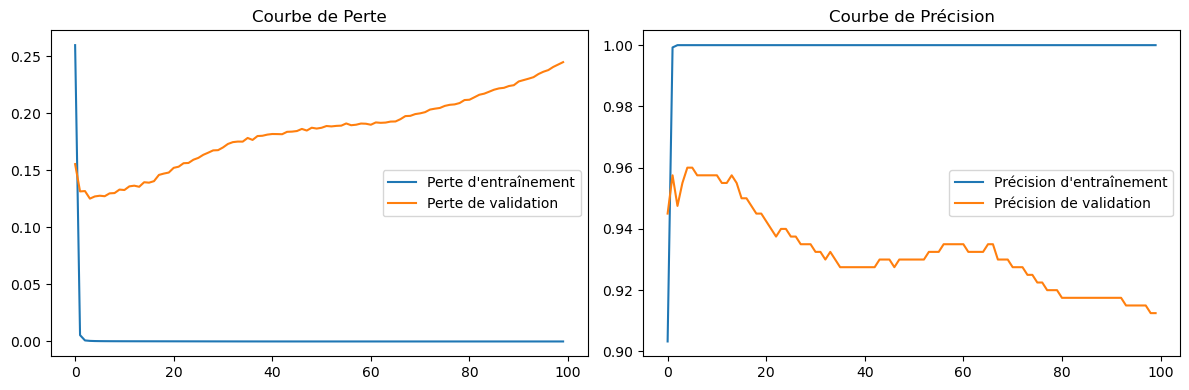

In [10]:
# 1. Évaluation du modèle sur les données de test
print("\n--- Évaluation finale sur le jeu de test ---")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=2)

# 2. Afficher la précision du modèle
print(f'Précision sur les données de test : {test_accuracy*100:.2f}%')

# 3. Afficher les courbes d'apprentissage

plt.figure(figsize=(12, 4))

# Graphique de la Perte (Loss)
plt.subplot(1, 2, 1)
plt.plot(historique.history['loss'], label='Perte d\'entraînement')
plt.plot(historique.history['val_loss'], label='Perte de validation')
plt.legend()
plt.title('Courbe de Perte')

# Graphique de la Précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historique.history['accuracy'], label='Précision d\'entraînement')
plt.plot(historique.history['val_accuracy'], label='Précision de validation')
plt.legend()
plt.title('Courbe de Précision')

plt.tight_layout()
plt.savefig('ERREUR')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


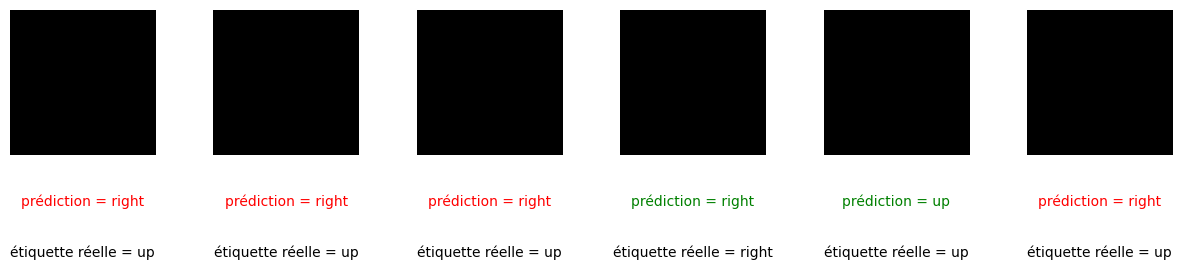

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définition des classes réelles (Directions)
CLASSES = np.array(["down", "left", "right", "up"]) 

# 2. Extraction d'un lot d'images et de labels du dataset de test
images, labels = next(iter(test_ds.take(1)))

# 3. Prédiction des classes pour ce batch
predictions = model.predict(images)
predictions_simples = CLASSES[np.argmax(predictions, axis=-1)]

# Géreration des labels réels
if len(labels.shape) > 1:
    vraies_classes_simples = CLASSES[np.argmax(labels, axis=-1)]
else:
    vraies_classes_simples = CLASSES[labels.numpy().astype(int)]

# 4. Nombre d'images à afficher
n_a_afficher = 6  

indices = np.random.choice(range(len(images)), n_a_afficher)

# 5. Créetion de la figure pour l'affichage
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    image = images[idx].numpy().astype("uint8")
    ax = fig.add_subplot(1, n_a_afficher, i + 1)
    ax.axis("off")
    
    # Vert si correct, rouge si erreur
    couleur = "green" if predictions_simples[idx] == vraies_classes_simples[idx] else "red"
    
    ax.text(
        0.5, -0.35,
        "prédiction = " + str(predictions_simples[idx]),
        fontsize=10, ha="center", transform=ax.transAxes, color=couleur
    )
    ax.text(
        0.5, -0.7,
        "étiquette réelle = " + str(vraies_classes_simples[idx]),
        fontsize=10, ha="center", transform=ax.transAxes
    )
    ax.imshow(image)
plt.savefig('IMAGE1')
plt.show()

# 3- Modèle CNN

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_cnn = Sequential()

# Première couche : input_shape doit correspondre à (180, 180, 3) pour les données
model_cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.5))

# Sortie : 4 classes (left, right, up, down)
model_cnn.add(Dense(4, activation='softmax'))

C:\Users\djafa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)

In [21]:
# Entraînement du modèle CNN
epochs = 10

history_cnn = model_cnn.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=epochs
)

# Évaluation du modèle sur les données de test
test_loss, test_accuracy = model_cnn.evaluate(test_ds, verbose=2)

print(f'Précision sur les données de test : {test_accuracy*100:.2f}%')

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 140s 544ms/step - accuracy: 0.9274 - loss: 0.1966 - val_accuracy: 0.9400 - val_loss: 0.1347
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - accuracy: 0.9956 - loss: 0.0167 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 146s 582ms/step - accuracy: 0.9976 - loss: 0.0079 - val_accuracy: 0.9975 - val_loss: 0.0125
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 566ms/step - accuracy: 0.9973 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 4.2618e-04
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 556ms/step - accuracy: 0.9970 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 3.4830e-04
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 559ms/step - accuracy: 0.9973 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 149s 594ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 3.0341e-04
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 557ms/step - accura


--- Évaluation finale sur le jeu de test ---
38/38 - 7s - 177ms/step - accuracy: 0.9725 - loss: 0.0870
Précision sur les données de test : 97.25%


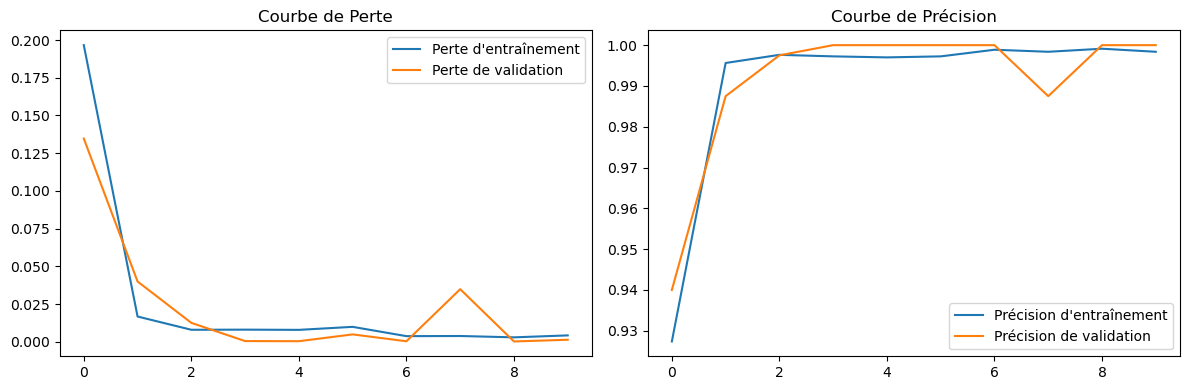

In [22]:
# 1. Évaluation du modèle sur les données de test
print("\n--- Évaluation finale sur le jeu de test ---")
test_loss, test_accuracy = model_cnn.evaluate(test_ds, verbose=2)

# 2. Afficher la précision du modèle
print(f'Précision sur les données de test : {test_accuracy*100:.2f}%')

# 3. Afficher les courbes d'apprentissage
plt.figure(figsize=(12, 4))

# Graphique de la Perte (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Perte d\'entraînement')
plt.plot(history_cnn.history['val_loss'], label='Perte de validation')
plt.legend()
plt.title('Courbe de Perte')

# Graphique de la Précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history_cnn.history['val_accuracy'], label='Précision de validation')
plt.legend()
plt.title('Courbe de Précision')

plt.tight_layout()
plt.savefig('ERREUR2')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step


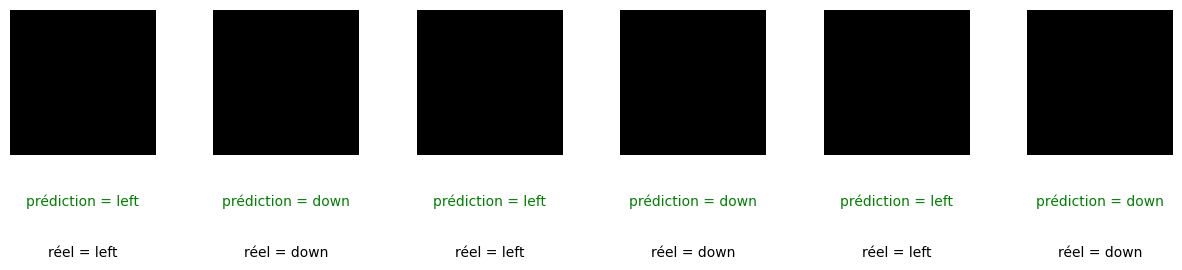

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Définit tes classes 
CLASSES = np.array(['left', 'right', 'up', 'down']) 

# 2. Récupérer un lot (batch) d'images de test
images, labels = next(iter(test_ds.take(1)))

# 3. Prédire les classes avec ton CNN
predictions = model_cnn.predict(images) 
predictions_simples = CLASSES[np.argmax(predictions, axis=-1)]

# Gérer les labels réels )
if len(labels.shape) > 1:
    vraies_classes_simples = CLASSES[np.argmax(labels, axis=-1)]
else:
    vraies_classes_simples = CLASSES[labels.numpy().astype(int)]

# 4. Nombre d'images à afficher
n_a_afficher = 6
indices = np.random.choice(range(len(images)), min(n_a_afficher, len(images)))

# 5. Créer la figure
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, idx in enumerate(indices):
    image = images[idx].numpy().astype("uint8")
    ax = fig.add_subplot(1, n_a_afficher, i + 1)
    ax.axis("off")
    
    # Conversion forcée en str pour éviter l'erreur d'ambiguïté
    pred_nom = str(predictions_simples[idx])
    reel_nom = str(vraies_classes_simples[idx])
    
    # Vert si correct, rouge si erreur
    couleur = "green" if pred_nom == reel_nom else "red"
    
    ax.text(0.5, -0.35, "prédiction = " + pred_nom, 
            fontsize=10, ha="center", transform=ax.transAxes, color=couleur)
    ax.text(0.5, -0.7, "réel = " + reel_nom, 
            fontsize=10, ha="center", transform=ax.transAxes)
    
    ax.imshow(image)
plt.savefig('PREDIT_CNN')
plt.show()

# 4- Pipeline de Reconnaissance Gestuelle : Intégration d'un Modèle CNN via OpenCV pour l'Interfaçage Homme-Machine (IHM)

In [29]:

# Sauvegarde impérative pour le script Python
model_cnn.save('model_cnn_gestes.keras')

In [30]:

import cv2
import numpy as np
import tensorflow as tf
import sys
import os

# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_PATH = 'model_cnn_gestes.keras'   # chemin vers le modèle sauvegardé
CLASSES     = ['left', 'right', 'up', 'down']
IMAGE_SIZE  = (180, 180)
CAMERA_ID   = 0                        # 0 = webcam principale

# Taille du carré de capture affiché à l'écran (dans le coin)
BOX_SIZE    = 180

# Seuil de confiance pour afficher la prédiction
CONFIDENCE_THRESHOLD = 0.6
# ──────────────────────────────────────────────────────────────────────────────

# Couleurs BGR pour chaque classe
COULEURS = {
    'left':  (255, 100,   0),
    'right': (  0, 200,  50),
    'up':    (  0, 100, 255),
    'down':  (200,   0, 200),
}

FLECHES = {
    'left':  '<-- GAUCHE',
    'right': 'DROITE -->',
    'up':    '^^ HAUT ^^',
    'down':  'vv BAS vv',
}


def charger_modele(path):
    if not os.path.exists(path):
        print(f"[ERREUR] Modèle introuvable : {path}")
        print()
        print("  Dans ton notebook Jupyter, exécute cette cellule puis relance ce script :")
        print("      model_cnn.save('model_cnn_gestes.h5')")
        sys.exit(1)
    print(f"[INFO] Chargement du modèle depuis {path} ...")
    model = tf.keras.models.load_model(path)
    model.summary()
    return model


def preprocess(frame_roi):
    """Redimensionne et normalise une région d'image pour le CNN."""
    img = cv2.resize(frame_roi, IMAGE_SIZE)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=0)   # (1, 180, 180, 3)


def draw_overlay(frame, label, confidence, couleur):
    h, w = frame.shape[:2]

    # Barre de fond en bas
    cv2.rectangle(frame, (0, h - 80), (w, h), (30, 30, 30), -1)

    texte_geste = FLECHES.get(label, label.upper())
    cv2.putText(frame, texte_geste, (20, h - 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.4, couleur, 3, cv2.LINE_AA)

    conf_texte = f"{confidence*100:.1f}%"
    cv2.putText(frame, conf_texte, (w - 130, h - 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, couleur, 2, cv2.LINE_AA)


def draw_zone(frame):
    """Dessine le rectangle de la zone analysée (coin supérieur gauche)."""
    cv2.rectangle(frame, (10, 10), (10 + BOX_SIZE, 10 + BOX_SIZE),
                  (0, 255, 255), 2)
    cv2.putText(frame, "Zone analysee", (10, 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1, cv2.LINE_AA)


def main():
    model = charger_modele(MODEL_PATH)

    cap = cv2.VideoCapture(CAMERA_ID)
    if not cap.isOpened():
        print(f"[ERREUR] Impossible d'ouvrir la caméra (ID={CAMERA_ID})")
        sys.exit(1)

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    print("\n[INFO] Caméra ouverte. Appuie sur 'q' pour quitter.\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("[ERREUR] Impossible de lire la frame.")
            break

        # Région d'intérêt = coin supérieur gauche
        roi = frame[10:10 + BOX_SIZE, 10:10 + BOX_SIZE]

        # Prédiction
        input_tensor = preprocess(roi)
        predictions  = model.predict(input_tensor, verbose=0)[0]   # (4,)
        idx          = int(np.argmax(predictions))
        confidence   = float(predictions[idx])
        label        = CLASSES[idx]
        couleur      = COULEURS[label]

        # Affichage
        draw_zone(frame)

        if confidence >= CONFIDENCE_THRESHOLD:
            draw_overlay(frame, label, confidence, couleur)
        else:
            h = frame.shape[0]
            cv2.rectangle(frame, (0, h - 80), (frame.shape[1], h), (30, 30, 30), -1)
            cv2.putText(frame, "Incertain...", (20, h - 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (150, 150, 150), 2)

        # Mini-barre de confiance pour chaque classe
        for i, (cls, prob) in enumerate(zip(CLASSES, predictions)):
            bar_w = int(prob * 150)
            y = 20 + i * 28
            cv2.rectangle(frame, (frame.shape[1] - 170, y),
                          (frame.shape[1] - 170 + bar_w, y + 18),
                          COULEURS[cls], -1)
            cv2.putText(frame, f"{cls} {prob*100:.0f}%",
                        (frame.shape[1] - 170, y + 14),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

        cv2.imshow("CNN - Test en temps reel (appuie Q pour quitter)", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("[INFO] Terminé.")


if __name__ == '__main__':
    main()


[INFO] Chargement du modèle depuis model_cnn_gestes.keras ...


C:\Users\djafa\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    15,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,334,090 (115.72 MB)

 Trainable params: 15,167,044 (57.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,167,046 (57.86 MB)


[INFO] Caméra ouverte. Appuie sur 'q' pour quitter.

[INFO] Terminé.
